In [534]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

In [535]:
input_file = 'data-19.txt'
data = pd.read_csv(input_file, delim_whitespace=True, header=None, names=['t', 'y'])
t = data['t'].values
y = data['y'].values

In [536]:
def model1(t, alpha0, alpha1, alpha2, beta1, beta2):
    return alpha0 + alpha1 * np.exp(beta1 * t) + alpha2 * np.exp(beta2 * t)

def objective_function1(params, t, y):
    alpha0, alpha1, alpha2, beta1, beta2 = params
    return np.sum((y - model1(t, alpha0, alpha1, alpha2, beta1, beta2))**2)

def gradient_1(params, t, y):
    alpha0, alpha1, alpha2, beta1, beta2 = params
    grad_alpha0 = -2 * np.sum(y - model1(t, alpha0, alpha1, alpha2, beta1, beta2))
    grad_alpha1 = -2 * np.sum((y - model1(t, alpha0, alpha1, alpha2, beta1, beta2)) * np.exp(beta1 * t))
    grad_alpha2 = -2 * np.sum((y - model1(t, alpha0, alpha1, alpha2, beta1, beta2)) * np.exp(beta2 * t))
    grad_beta1 = -2 * np.sum((y - model1(t, alpha0, alpha1, alpha2, beta1, beta2)) * alpha1 * t * np.exp(beta1 * t))
    grad_beta2 = -2 * np.sum((y - model1(t, alpha0, alpha1, alpha2, beta1, beta2)) * alpha2 * t * np.exp(beta2 * t))
    return np.array([grad_alpha0, grad_alpha1, grad_alpha2, grad_beta1, grad_beta2])

def hessian_1(params, t, y):
    alpha0, alpha1, alpha2, beta1, beta2 = params
    h11 = 2 * len(t)
    h12 = 2 * np.sum(np.exp(beta1 * t))
    h13 = 2 * np.sum(np.exp(beta2 * t))
    h14 = 2 * np.sum(alpha1 * t * np.exp(beta1 * t))
    h15 = 2 * np.sum(alpha2 * t * np.exp(beta2 * t))
    h22 = 2 * np.sum(t**2 * np.exp(2 * beta1 * t))
    h23 = 2 * np.sum(t * np.exp((beta1 + beta2) * t))
    h24 = 2 * np.sum(alpha1 * t**2 * np.exp(2 * beta1 * t))
    h25 = 2 * np.sum(alpha2 * t**2 * np.exp((beta1 + beta2) * t))
    h33 = 2 * np.sum(t**2 * np.exp(2 * beta2 * t))
    h34 = 2 * np.sum(alpha1 * t**2 * np.exp((beta1 + beta2) * t))
    h35 = 2 * np.sum(alpha2 * t**2 * np.exp(2 * beta2 * t))
    h44 = 2 * np.sum(alpha1**2 * t**2 * np.exp(2 * beta1 * t))
    h45 = 2 * np.sum(alpha1 * alpha2 * t**2 * np.exp((beta1 + beta2) * t))
    h55 = 2 * np.sum(alpha2**2 * t**2 * np.exp(2 * beta2 * t))
    hessian = np.array([[h11, h12, h13, h14, h15],
                        [h12, h22, h23, h24, h25],
                        [h13, h23, h33, h34, h35],
                        [h14, h24, h34, h44, h45],
                        [h15, h25, h35, h45, h55]])
    return hessian

def iterative_1(t, y, initial_params, max_iter=100000, tol=1e-3, mu=1.0):
    params = initial_params
    for i in range(max_iter):
        gradient = gradient_1(params, t, y)
        hessian = hessian_1(params, t, y)
        
        diag_hessian = np.diag(hessian)
        damping = mu * np.max(diag_hessian)
        hessian_lm = hessian + damping * np.eye(len(params))
        
        try:
            delta_params = np.linalg.solve(hessian_lm, gradient)
            params = params - delta_params
        except np.linalg.LinAlgError:
            print(f"iteration {i}: Hessian matrix is not invertible.")
            mu *= 10 
            continue
        
        if np.linalg.norm(gradient) < tol:
            print(f"converged in {i+1} iterations.")
            return params
        
        # Update the damping factor
        if np.linalg.norm(delta_params) < tol:
            mu /= 10
        else:
            mu *= 10
    
    print("Algorithm did not converge.")
    return params
initial_guess_1 = [-1.29, 0.01, 0.01, 0.01,1]
params_1 = iterative_1(t, y, initial_guess_1)
print(params_1)

Algorithm did not converge.
[-3.62474228 -2.88994984  5.12726893 -1.93735236  0.18502984]


In [537]:
def model2(t, alpha0, alpha1, beta0, beta1):
    return (alpha0 + alpha1 * t) / (beta0 + beta1 * t)

def objective_function2(params, t, y):
    alpha0, alpha1, beta0, beta1 = params
    return np.sum((y - model2(t, alpha0, alpha1, beta0, beta1))**2)

def gradient_2(params, t, y):
    alpha0, alpha1, beta0, beta1 = params
    model_values = model2(t, alpha0, alpha1, beta0, beta1)
    residuals = y - model_values
    denominator = (beta0 + beta1 * t)

    grad_alpha0 = -2 * np.sum(residuals / denominator)
    grad_alpha1 = -2 * np.sum(residuals * t / denominator)
    grad_beta0 = 2 * np.sum(residuals * model_values / denominator)
    grad_beta1 = 2 * np.sum(residuals * model_values * t / denominator)

    return np.array([grad_alpha0, grad_alpha1, grad_beta0, grad_beta1])

def hessian_2(params, t, y):
    alpha0, alpha1, beta0, beta1 = params
    model_values = model2(t, alpha0, alpha1, beta0, beta1)
    residuals = y - model_values
    denominator = (beta0 + beta1 * t)
    denominator_squared = denominator ** 2

    # Hessian calculation
    h11 = 2 * len(t) / np.mean(denominator_squared)
    h12 = 2 * np.sum(t / denominator_squared)
    h13 = -2 * np.sum((t * model_values) / denominator_squared)
    h14 = -2 * np.sum((t * model_values) / denominator_squared)
    
    h22 = 2 * np.sum(t**2 / denominator_squared)
    h23 = 2 * np.sum((t**2 * model_values) / denominator_squared)
    h24 = 2 * np.sum(t**2 * model_values / denominator_squared)
    
    h33 = 2 * np.sum((model_values**2) / denominator_squared)
    h34 = 2 * np.sum((model_values**2 * t) / denominator_squared)
    h44 = 2 * np.sum(model_values**2 / denominator_squared)
    
    hessian = np.array([[h11, h12, h13, h14],
                        [h12, h22, h23, h24],
                        [h13, h23, h33, h34],
                        [h14, h24, h34, h44]])
    
    return hessian

def iterative_2(t, y, initial_params, max_iter=100000, tol=1e-3, mu=1.0):
    params = initial_params
    for i in range(max_iter):
        gradient = gradient_2(params, t, y)
        hessian = hessian_2(params, t, y)

        diag_hessian = np.diag(hessian)
        damping = mu * np.max(diag_hessian)
        hessian_lm = hessian + damping * np.eye(len(params))

        try:
            delta_params = np.linalg.solve(hessian_lm, gradient)
            params = params - delta_params
        except np.linalg.LinAlgError:
            print(f"iteration {i}: Hessian matrix is not invertible.")
            mu *= 10
            continue

        if np.linalg.norm(gradient) < tol:
            print(f"converged in {i+1} iterations.")
            return params

        if np.linalg.norm(delta_params) < tol:
            mu /= 10
        else:
            mu *= 10

    print("Algorithm did not converge.")
    return params


initial_guess_2 = [-1.3, 0.05, .05, 0.1]
params_2 = iterative_2(t, y, initial_guess_2)
print(params_2)


converged in 72220 iterations.
[-6.58669288 25.48505073  4.74862405  4.15275171]


In [538]:
def model3(t, beta0, beta1, beta2, beta3, beta4):
    return beta0 + beta1 * t + beta2 * (t**2) + beta3 * (t**3) + beta4 * (t**4)

def objective_function3(params, t, y):
    beta0, beta1, beta2, beta3, beta4 = params
    return np.sum((y - model3(t, beta0, beta1, beta2, beta3, beta4))**2)

def gradient_3(params, t, y):
    beta0, beta1, beta2, beta3, beta4 = params
    grad_beta0 = -2 * np.sum(y - model3(t, beta0, beta1, beta2, beta3, beta4))
    grad_beta1 = -2 * np.sum((y - model3(t, beta0, beta1, beta2, beta3, beta4)) * t)
    grad_beta2 = -2 * np.sum((y - model3(t, beta0, beta1, beta2, beta3, beta4)) * t**2)
    grad_beta3 = -2 * np.sum((y - model3(t, beta0, beta1, beta2, beta3, beta4)) * t**3)
    grad_beta4 = -2 * np.sum((y - model3(t, beta0, beta1, beta2, beta3, beta4)) * t**4)
    return np.array([grad_beta0, grad_beta1, grad_beta2, grad_beta3, grad_beta4])

def hessian_3(params, t, y):
    beta0, beta1, beta2, beta3, beta4 = params
    h11 = 2 * len(t)
    h12 = 2 * np.sum(t)
    h13 = 2 * np.sum(t**2)
    h14 = 2 * np.sum(t**3)
    h15 = 2 * np.sum(t**4)
    h22 = 2 * np.sum(t**2)
    h23 = 2 * np.sum(t**3)
    h24 = 2 * np.sum(t**4)
    h25 = 2 * np.sum(t**5)
    h33 = 2 * np.sum(t**4)
    h34 = 2 * np.sum(t**5)
    h35 = 2 * np.sum(t**6)
    h44 = 2 * np.sum(t**6)
    h45 = 2 * np.sum(t**7)
    h55 = 2 * np.sum(t**8)
    hessian = np.array([[h11, h12, h13, h14, h15],
                        [h12, h22, h23, h24, h25],
                        [h13, h23, h33, h34, h35],
                        [h14, h24, h34, h44, h45],
                        [h15, h25, h35, h45, h55]])
    return hessian

def iterative_3(t, y, initial_params, max_iter=100000, tol=1e-3, mu=1.0):
    params = initial_params
    for i in range(max_iter):
        gradient = gradient_3(params, t, y)
        hessian = hessian_3(params, t, y)
    
        diag_hessian = np.diag(hessian)
        damping = mu * np.max(diag_hessian)
        hessian_lm = hessian + damping * np.eye(len(params))
        
        try:
            delta_params = np.linalg.solve(hessian_lm, gradient)
            params = params - delta_params
        except np.linalg.LinAlgError:
            print(f"iteration {i}: Hessian matrix is not invertible.")
            mu *= 10  
            continue
        
        if np.linalg.norm(gradient) < tol:
            print(f"converged in {i+1} iterations.")
            return params
        
        if np.linalg.norm(delta_params) < tol:
            mu /= 10
        else:
            mu *= 10
    
    print("Algorithm did not converge.")
    return params

initial_guess_3 = [0, 1, 0.1, 0.01, 0.001]
params_3 = iterative_3(t, y, initial_guess_3)
print(params_3)

converged in 7194 iterations.
[-1.35186692  5.95084876 -2.95832738 -0.05561985  0.53738942]


In [539]:
params_1

array([-3.62474228, -2.88994984,  5.12726893, -1.93735236,  0.18502984])

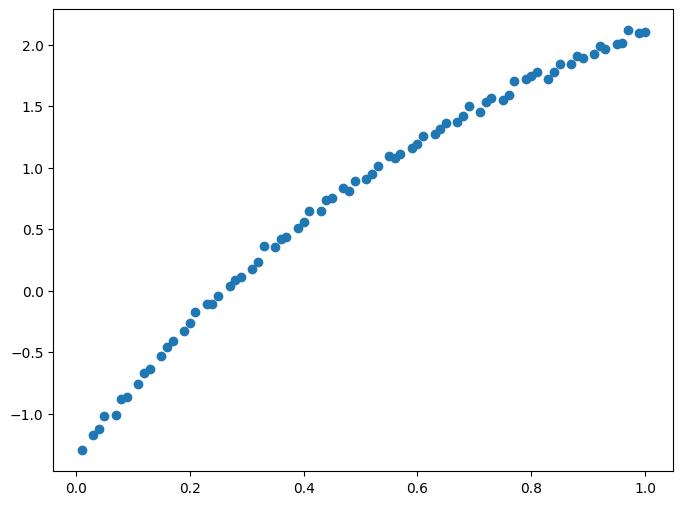

In [556]:
plt.figure(figsize=(8, 6))
plt.plot(t, y,'o', label="True data")  # True data points
y_fit_1 = model1(t, *params_1)  # Fitted curve
y_fit_2 = model2(t, *params_2)
y_fit_3 = model3(t, *params_3)


In [541]:
def log_likelihood(model, params, t, y):
    residuals = y - model(t, *params)
    log_likelihood = -0.5 * np.sum(residuals**2)  
    return log_likelihood

def calculate_aic(model, params, t, y):
    k = len(params)  # Number of parameters
    L = log_likelihood(model, params, t, y)  # Log-likelihood
    aic = 2 * k - 2 * L  # AIC formula
    return aic

In [542]:
# AKAIKE-INFORMATION-CRITERION
aic1 = calculate_aic(model1, params_1, t, y)
aic2 = calculate_aic(model2, params_2, t, y)
aic3 = calculate_aic(model3, params_3, t, y)

best_model = min((aic1, 'Model 1'), (aic2, 'Model 2'), (aic3, 'Model 3'), key=lambda x: x[0])
best_model

(8.060078928425602, 'Model 2')

In [543]:
from scipy import stats
stat, p_value = stats.shapiro(res_2)
print(f"Test Statistic (W): {stat}")
print(f"P-value: {p_value}")
alpha = 0.05 
if p_value > alpha:
    print("Fail to reject the null hypothesis: Data is likely normally distributed.")
else:
    print("Reject the null hypothesis: Data is not normally distributed.")

Test Statistic (W): 0.9734617471694946
P-value: 0.11625553667545319
Fail to reject the null hypothesis: Data is likely normally distributed.


In [544]:
def calculate_sigma_squared(y_true, y_pred, num_params):
    residuals = y_true - y_pred
    n = len(y_true)
    RSS = np.sum(residuals**2)
    sigma_squared = RSS / (n - num_params)
    return sigma_squared

def estimate_sigma_all_models(y, y_fit_1, y_fit_2, y_fit_3):
    sigma_sq = {
        'Model 1': calculate_sigma_squared(y, y_fit_1, 5),  # α₀, α₁, α₂, β₁, β₂
        'Model 2': calculate_sigma_squared(y, y_fit_2, 4),  # α₀, α₁, β₀, β₁
        'Model 3': calculate_sigma_squared(y, y_fit_3, 5)   # β₀, β₁, β₂, β₃, β₄
    }
    return sigma_sq

sigma_square = estimate_sigma_all_models(y,y_fit_1,y_fit_2,y_fit_3)
print(sigma_square)

{'Model 1': 0.000874646227357466, 'Model 2': 0.0008461820905014451, 'Model 3': 0.0008393221310642815}


In [545]:
res_1 = y-y_fit_1
sigma_squared_1 = calculate_sigma_squared(y, y_fit_1, 5)
print(sigma_squared_1)
res_2 = y-y_fit_2
sigma_squared_2 = calculate_sigma_squared(y, y_fit_2, 4)
print(sigma_squared_2)

res_3 = y-y_fit_3
sigma_squared_3 = calculate_sigma_squared(y, y_fit_3, 5)
print(sigma_squared_3)

0.000874646227357466
0.0008461820905014451
0.0008393221310642815


In [546]:
print(np.sum(res_1), np.sum(res_2), np.sum(res_3))

-2.1893506772840965e-05 -0.0020766005208042726 -3.4085240820658225e-06


In [547]:
from scipy import stats
stat, p_value = stats.shapiro(res_2)
print(f"Test Statistic (W): {stat}")
print(f"P-value: {p_value}")
alpha = 0.05 
if p_value > alpha:
    print("Fail to reject the null hypothesis: Data is likely normally distributed.")
else:
    print("Reject the null hypothesis: Data is not normally distributed.")

Test Statistic (W): 0.9734617471694946
P-value: 0.11625553667545319
Fail to reject the null hypothesis: Data is likely normally distributed.


In [548]:
data = res_2
mean = np.mean(data)
std = np.std(data)

# Perform Kolmogorov-Smirnov Test (One-sample test)
D_stat, p_value = stats.kstest(data, 'norm', args=(mean, std))

# Output results
print(f"KS Test Statistic (D): {D_stat}")
print(f"P-value: {p_value}")

# Interpretation
alpha = 0.05  
if p_value > alpha:
    print("Fail to reject the null hypothesis: Data is likely normally distributed.")
else:
    print("Reject the null hypothesis: Data is not normally distributed.")

KS Test Statistic (D): 0.09770747586363393
P-value: 0.4431665864728548
Fail to reject the null hypothesis: Data is likely normally distributed.


In [549]:
def jacobian_model1(t, *params):
    alpha0, alpha1, beta1, alpha2, beta2 = params
    n = len(t)
    J = np.zeros((n, 5))
    J[:, 0] = 1                                # d/d(alpha0)
    J[:, 1] = np.exp(beta1 * t)                # d/d(alpha1)
    J[:, 2] = alpha1 * t * np.exp(beta1 * t)   # d/d(beta1)
    J[:, 3] = np.exp(beta2 * t)                # d/d(alpha2)
    J[:, 4] = alpha2 * t * np.exp(beta2 * t)   # d/d(beta2)
    return J

def jacobian_model2(t, alpha0, alpha1, beta0, beta1, epsilon=1e-5):
    # Compute the Jacobian matrix for model2
    denom = beta0 + beta1 * t
    jacobian = np.zeros((len(t), 4))  # Jacobian with shape (75, 4)
    
    jacobian[:, 0] = 1 / denom  # Derivative w.r.t alpha0
    jacobian[:, 1] = t / denom  # Derivative w.r.t alpha1
    jacobian[:, 2] = -(alpha0 + alpha1 * t) / (denom ** 2)  # Derivative w.r.t beta0
    jacobian[:, 3] = -(alpha0 + alpha1 * t) * t / (denom ** 2)  # Derivative w.r.t beta1
    

    for i in range(4):  # Loop through the parameters
        jacobian[:, i] += epsilon * np.eye(len(t))[i]
    return jacobian
                                                   
def jacobian_model3(t, *params):
    beta0, beta1, beta2, beta3, beta4 = params
    n = len(t)
    J = np.zeros((n, 5))
    
    # Partial derivatives
    J[:, 0] = 1           # d/d(beta0)
    J[:, 1] = t           # d/d(beta1)
    J[:, 2] = t**2        # d/d(beta2)
    J[:, 3] = t**3        # d/d(beta3)
    J[:, 4] = t**4        # d/d(beta4)
    
    return J

In [550]:
jacobian_model2(t,*params_2)

array([[ 0.20877166,  0.00208762,  0.27595075,  0.00275951],
       [ 0.20520369,  0.00616611,  0.24516197,  0.00735486],
       [ 0.20346981,  0.00813879,  0.23049563,  0.00921943],
       [ 0.20176497,  0.01008825,  0.21626469,  0.01082323],
       [ 0.1984396 ,  0.01389077,  0.1891236 ,  0.01323865],
       [ 0.19681769,  0.01574541,  0.17617249,  0.0140938 ],
       [ 0.19522207,  0.01756999,  0.1636148 ,  0.01472533],
       [ 0.19210721,  0.02113179,  0.13962474,  0.01535872],
       [ 0.19058676,  0.02287041,  0.12816633,  0.01537996],
       [ 0.18909019,  0.02458172,  0.11704919,  0.01521639],
       [ 0.18616646,  0.02792497,  0.09579233,  0.01436885],
       [ 0.18473824,  0.02955812,  0.08563059,  0.0137009 ],
       [ 0.18333177,  0.0311664 ,  0.07576603,  0.01288023],
       [ 0.18058212,  0.0343106 ,  0.05688906,  0.01080892],
       [ 0.17923799,  0.0358476 ,  0.04785793,  0.00957159],
       [ 0.17791372,  0.03736188,  0.03908651,  0.00820817],
       [ 0.17532304,  0.

In [551]:
def compute_confidence_intervals(model, jacobian_func, t, y, *params):
    y_pred = model(t, *params)
    residuals = y - y_pred
    sigma_squared = np.sum(residuals ** 2) / (len(y) - len(params))
    J = jacobian_func(t, *params)

    
    fisher_info_matrix = (J.T @ J) / sigma_squared
    
    covariance_matrix = np.linalg.inv(fisher_info_matrix)
    
    standard_errors = np.sqrt(np.diag(covariance_matrix))
    
    z_score = 1.96
    confidence_intervals = [
        (param - z_score * se, param + z_score * se)
        for param, se in zip(params, standard_errors)
    ]
    
    return params, standard_errors, confidence_intervals

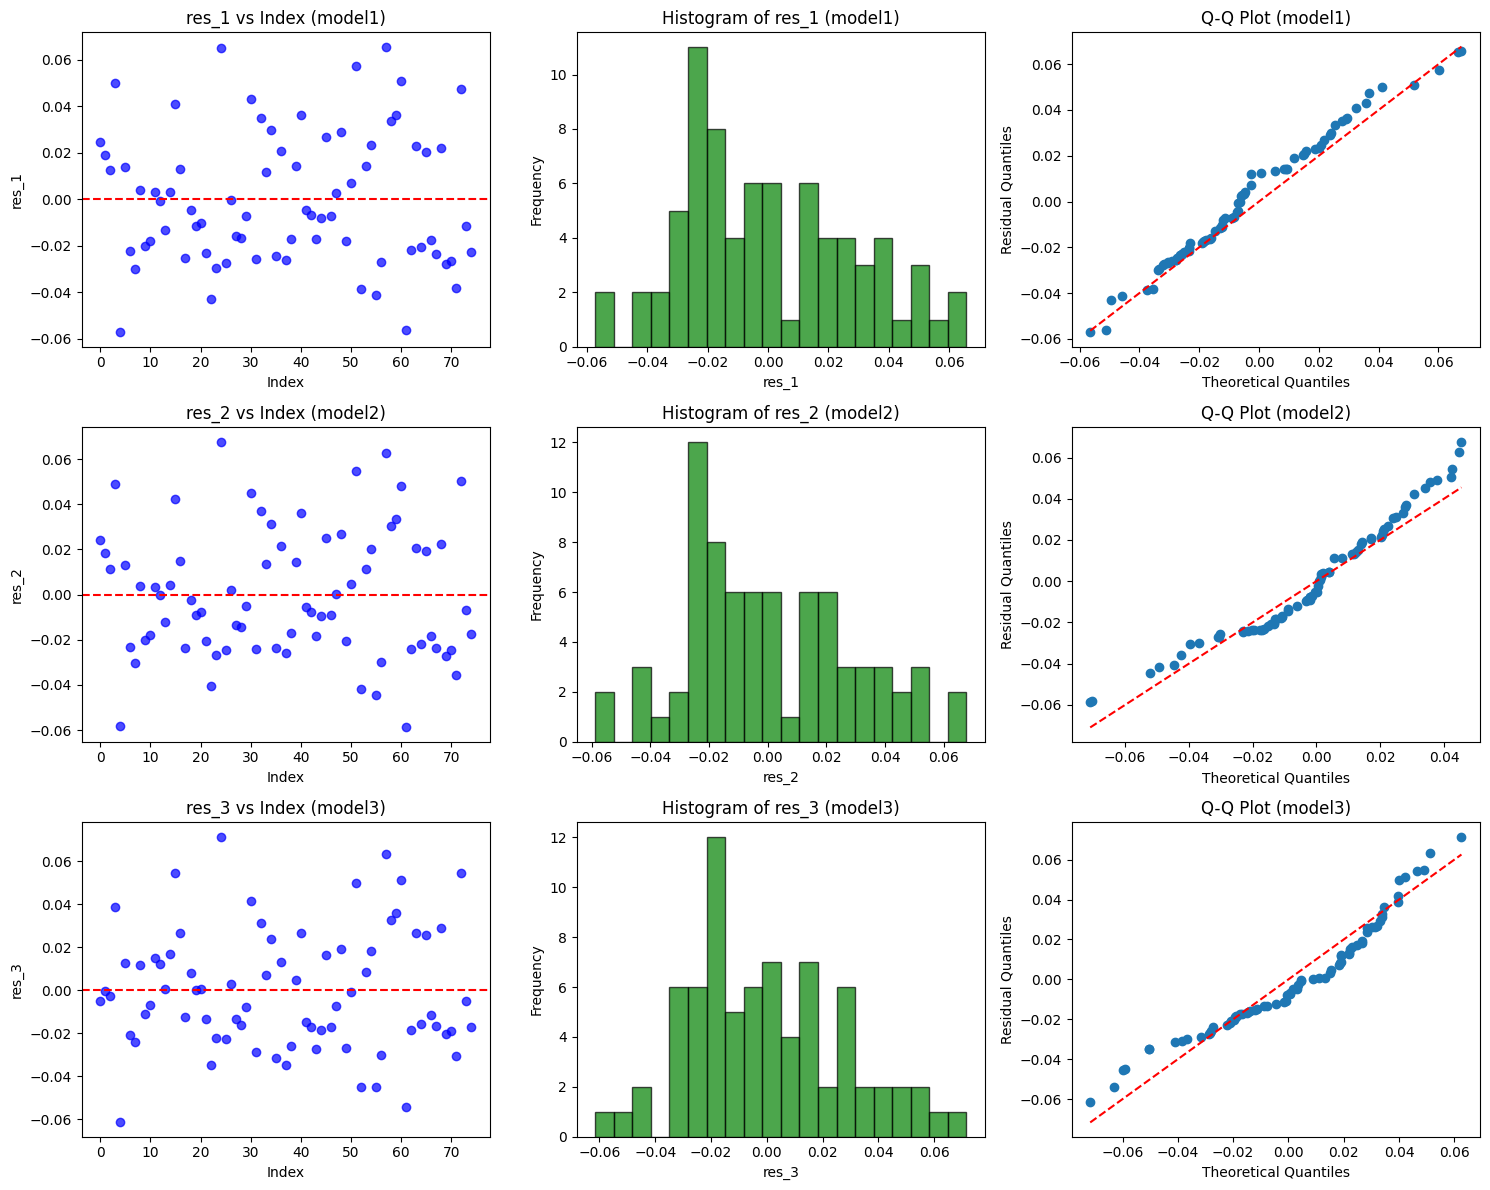

In [553]:
plt.figure(figsize=(15, 12))
plt.subplot(3, 3, 1)
plt.scatter(range(len(res_1)), res_1, alpha=0.7, color='blue')
plt.axhline(y=0, color='red', linestyle='--')
plt.title(f'res_1 vs Index (model1)')
plt.xlabel('Index')
plt.ylabel('res_1')

plt.subplot(3, 3, 2)
plt.hist(res_1, bins=20, alpha=0.7, edgecolor='black', color='green')
plt.title(f'Histogram of res_1 (model1)')
plt.xlabel('res_1')
plt.ylabel('Frequency')

plt.subplot(3, 3, 3)
sorted_res_1 = np.sort(res_1)
theoretical_quantiles = np.sort(np.random.normal(0, np.std(res_1), len(res_1)))
plt.plot(theoretical_quantiles, sorted_res_1, 'o')
plt.plot(theoretical_quantiles, theoretical_quantiles, 'r--')
plt.title(f'Q-Q Plot (model1)')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Residual Quantiles')

plt.subplot(3, 3, 4)
plt.scatter(range(len(res_2)), res_2, alpha=0.7, color='blue')
plt.axhline(y=0, color='red', linestyle='--')
plt.title(f'res_2 vs Index (model2)')
plt.xlabel('Index')
plt.ylabel('res_2')

plt.subplot(3, 3, 5)
plt.hist(res_2, bins=20, alpha=0.7, edgecolor='black', color='green')
plt.title(f'Histogram of res_2 (model2)')
plt.xlabel('res_2')
plt.ylabel('Frequency')

plt.subplot(3, 3, 6)
sorted_res_2 = np.sort(res_2)
theoretical_quantiles = np.sort(np.random.normal(0, np.std(res_2), len(res_2)))
plt.plot(theoretical_quantiles, sorted_res_2, 'o')
plt.plot(theoretical_quantiles, theoretical_quantiles, 'r--')
plt.title(f'Q-Q Plot (model2)')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Residual Quantiles')

plt.subplot(3, 3, 7)
plt.scatter(range(len(res_3)), res_3, alpha=0.7, color='blue')
plt.axhline(y=0, color='red', linestyle='--')
plt.title(f'res_3 vs Index (model3)')
plt.xlabel('Index')
plt.ylabel('res_3')


plt.subplot(3, 3, 8)
plt.hist(res_3, bins=20, alpha=0.7, edgecolor='black', color='green')
plt.title(f'Histogram of res_3 (model3)')
plt.xlabel('res_3')
plt.ylabel('Frequency')

plt.subplot(3, 3, 9)
sorted_res_3 = np.sort(res_3)
theoretical_quantiles = np.sort(np.random.normal(0, np.std(res_3), len(res_3)))
plt.plot(theoretical_quantiles, sorted_res_3, 'o')
plt.plot(theoretical_quantiles, theoretical_quantiles, 'r--')
plt.title(f'Q-Q Plot (model3)')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Residual Quantiles')

plt.tight_layout()
plt.show()

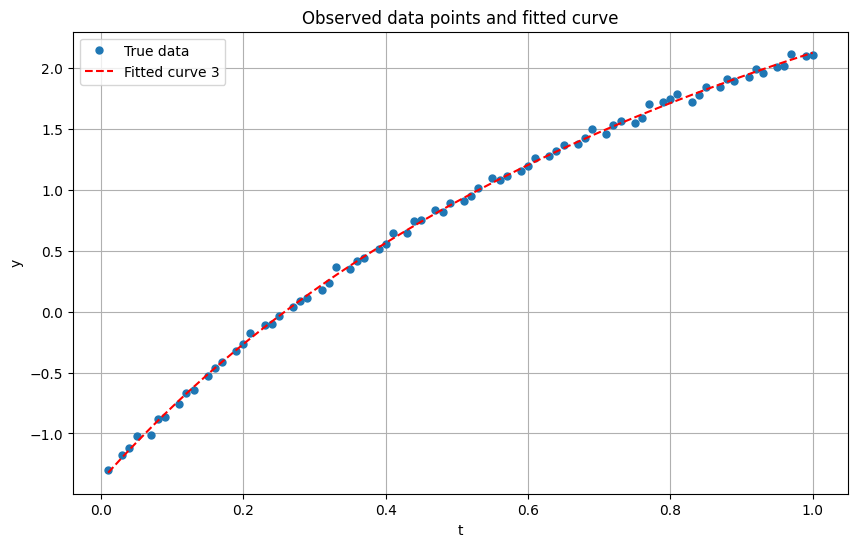

In [555]:
plt.figure(figsize=(10, 6))
plt.plot(t, y,'o', label="True data", markersize = 5) 
plt.plot(t, y_fit_2, label="Fitted curve 3", color = 'red', linestyle = '--')
plt.xlabel("t")
plt.ylabel("y")
plt.title("Observed data points and fitted curve")
plt.legend()
plt.grid(True)
plt.show()